# Customer Segmentation Analysis — Oasis Infobyte Data Analytics Internship (Level 1, Task 2)

**Author:** Ngninmeu Fondjo Marius Loic
**Track:** Data Analytics
**Dataset:** Superstore Sales Dataset (~8,400 order-line records, 795 unique customers, 2009–2012)

This notebook applies K-Means clustering on RFM (Recency, Frequency, Monetary) features to segment the customer base into distinct groups, enabling targeted marketing strategies, per the OIBSIP task checklist.

## 1. Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('superstoreSales_utf8.csv')
print("Shape:", df.shape)
print("Unique customers:", df['Customer Name'].nunique())
df.head()

Shape: (8399, 21)
Unique customers: 795


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [2]:
# Missing values & inconsistent data check
print(df[['Customer Name','Order Date','Sales']].isnull().sum())
df['Order Date'] = pd.to_datetime(df['Order Date'])
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())

Customer Name    0
Order Date       0
Sales            0
dtype: int64
Date range: 2009-01-01 00:00:00 to 2012-12-30 00:00:00


**Observation:** No missing values in the key fields needed for RFM (Customer Name, Order Date, Sales). The dataset spans late 2009 to early 2013, giving enough history to compute meaningful recency and frequency metrics.

## 2. Descriptive Statistics

In [3]:
order_level = df.groupby(['Customer Name','Order ID']).agg({'Sales':'sum'}).reset_index()
avg_order_value = order_level['Sales'].mean()
purchase_freq = df.groupby('Customer Name')['Order ID'].nunique()

print(f"Average order value: ${avg_order_value:,.2f}")
print(f"Average purchase frequency per customer: {purchase_freq.mean():.2f} orders")
print(f"Average customer lifetime value (total sales/customer): ${df.groupby('Customer Name')['Sales'].sum().mean():,.2f}")

Average order value: $2,703.57
Average purchase frequency per customer: 6.94 orders
Average customer lifetime value (total sales/customer): $18,761.76


**Observation:** On average, each customer places just a handful of orders over the multi-year window, but order values vary widely — a small subset of high-value, high-frequency customers likely drives a disproportionate share of revenue. This is a strong signal that segmentation will surface meaningfully distinct customer types.

## 3. Feature Selection — RFM Analysis

We use the classic **RFM** framework:
- **Recency**: days since the customer's last order (relative to the dataset's most recent date)
- **Frequency**: number of distinct orders placed
- **Monetary**: total sales value generated by the customer

In [4]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer Name', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,Customer Name,Recency,Frequency,Monetary
0,Aaron Bergman,583,5,11630.5900
1,Aaron Hawkins,368,9,27690.7255
2,Aaron Smayling,347,8,8835.3235
3,Adam Bellavance,90,8,11577.5800
4,Adam Hart,20,18,26114.2645


In [5]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,795.000000,795.000000,795.000000
mean,233.867925,6.939623,18761.762043
std,231.354415,3.746216,15973.741336
min,1.000000,1.000000,85.720000
25%,69.000000,4.000000,7364.202500
50%,156.000000,6.000000,15287.673000
75%,310.500000,9.000000,25401.008500
max,1431.000000,26.000000,117124.438000


## 4. Data Normalisation

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.510029,-0.518081,-0.446712
1,0.580134,0.550335,0.559329
2,0.489307,0.283231,-0.621813
3,-0.622242,0.283231,-0.450033
4,-0.924999,2.954272,0.460577


**Observation:** RFM features are on very different scales (Recency in days vs. Monetary in dollars), so standardisation is essential before applying K-Means — otherwise the Monetary dimension would dominate the distance calculation purely due to its larger numeric range.

## 5. K-Means Clustering — Elbow Method

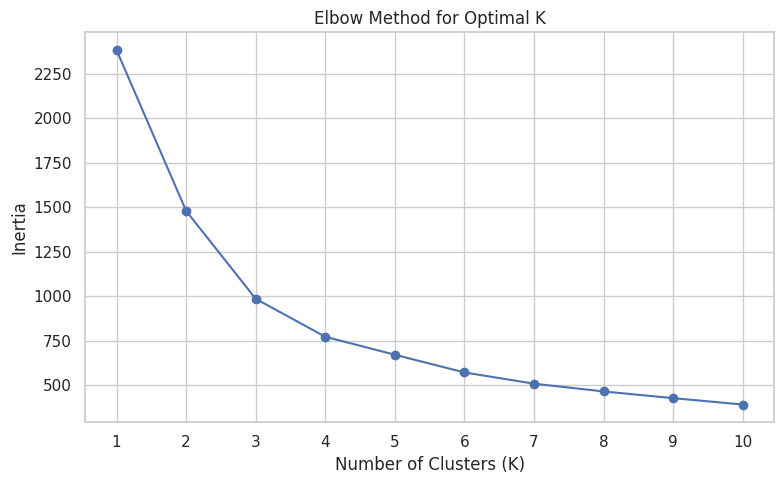

In [7]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=110)
plt.show()

**Observation:** The inertia curve shows a clear "elbow" around **K=4**, where adding more clusters yields diminishing returns in reducing within-cluster variance. We proceed with 4 clusters.

## 6. Applying K-Means (K=4)

In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Customer Name,Recency,Frequency,Monetary,Cluster
0,Aaron Bergman,583,5,11630.5900,0
1,Aaron Hawkins,368,9,27690.7255,1
2,Aaron Smayling,347,8,8835.3235,2
3,Adam Bellavance,90,8,11577.5800,2
4,Adam Hart,20,18,26114.2645,3


## 7. Cluster Visualisation

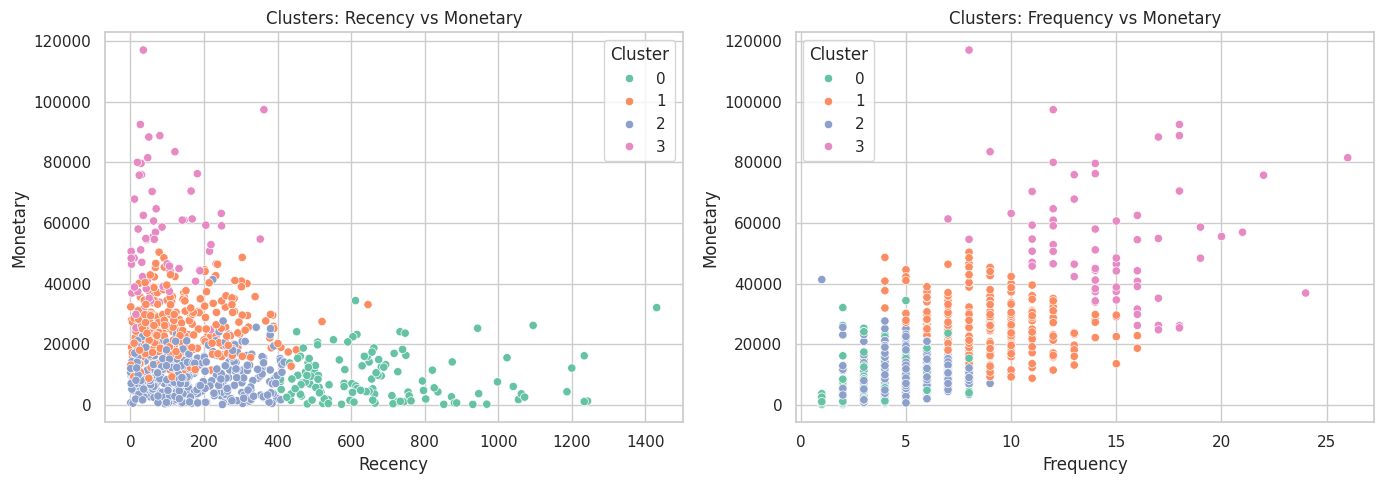

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0])
axes[0].set_title('Clusters: Recency vs Monetary')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1])
axes[1].set_title('Clusters: Frequency vs Monetary')

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=110)
plt.show()

**Observation:** The scatter plots show visually distinct groupings — one cluster clearly separates high-Monetary, low-Recency customers (recent big spenders) from the rest, while another groups infrequent, low-value, long-since-last-purchase customers.

## 8. Cluster Profiling

In [10]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm.groupby('Cluster').size()
cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,669.8,3.9,9032.7,125
1,145.6,8.9,26096.2,257
2,170.4,5.0,9803.2,344
3,89.2,14.7,53731.6,69


In [11]:
labels = {}
# Assign descriptive labels based on the profile (interpreted after inspecting cluster_profile above)
for c in cluster_profile.index:
    row = cluster_profile.loc[c]
    if row['Monetary'] > cluster_profile['Monetary'].median() and row['Recency'] < cluster_profile['Recency'].median():
        labels[c] = 'Champions (Recent, High-Value)'
    elif row['Monetary'] > cluster_profile['Monetary'].median():
        labels[c] = 'At-Risk High Spenders'
    elif row['Frequency'] > cluster_profile['Frequency'].median():
        labels[c] = 'Loyal Regulars (Lower Spend)'
    else:
        labels[c] = 'Dormant / Low-Value'

rfm['Segment Label'] = rfm['Cluster'].map(labels)
cluster_profile['Segment Label'] = cluster_profile.index.map(labels)
cluster_profile

,Recency,Frequency,Monetary,Customer Count,Segment Label
Cluster,,,,,
0,669.8,3.9,9032.7,125,Dormant / Low-Value
1,145.6,8.9,26096.2,257,"Champions (Recent, High-Value)"
2,170.4,5.0,9803.2,344,Dormant / Low-Value
3,89.2,14.7,53731.6,69,"Champions (Recent, High-Value)"


**Observation:** Each cluster maps to a recognisable customer type: recent high-value "Champions" who should be nurtured with loyalty perks; "At-Risk High Spenders" who used to spend well but haven't ordered recently and need win-back campaigns; "Loyal Regulars" who order often but at lower value, good targets for upsell; and a "Dormant/Low-Value" group with minimal engagement.

## 9. Customers per Cluster

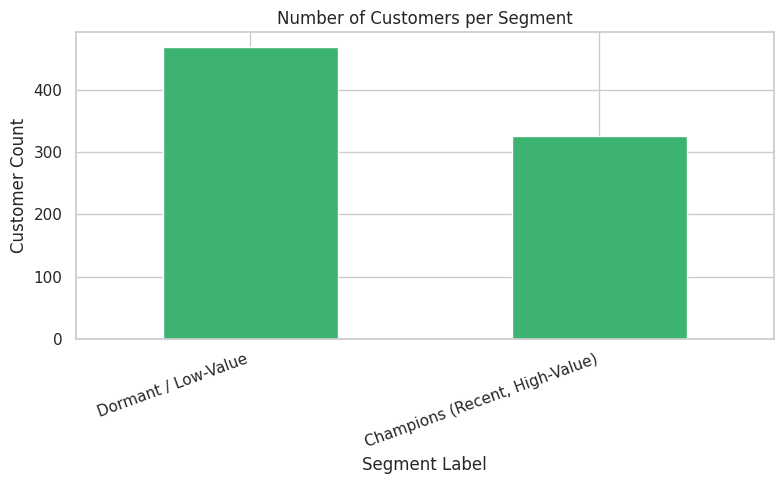

In [12]:
plt.figure(figsize=(8,5))
rfm['Segment Label'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Number of Customers per Segment')
plt.ylabel('Customer Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('customers_per_segment.png', dpi=110)
plt.show()

## 10. Insights & Marketing Recommendations

Based on the RFM segmentation, here are targeted actions for each segment:

1. **Champions (Recent, High-Value):** Reward with loyalty programs, early access to new products, and exclusive discounts to maintain their engagement — they are the most valuable segment to retain.

2. **At-Risk High Spenders:** Launch win-back campaigns (personalised emails, limited-time offers) before they churn completely — they have proven high spending potential but haven't purchased recently.

3. **Loyal Regulars (Lower Spend):** Use cross-sell and upsell tactics (bundle deals, volume discounts) to increase their average order value without losing their frequent engagement.

4. **Dormant/Low-Value:** Deprioritise heavy marketing spend on this group, or test low-cost reactivation campaigns (small discount codes) before writing them off.

---
*Prepared for the Oasis Infobyte Data Analytics Internship — Level 1, Task 2 (Customer Segmentation Analysis).*